In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, math
import numpy as np
import healpy as hp
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy import stats
from tqdm import tqdm

from msfm.grid_pipeline import GridPipeline
from msfm.utils import files, power_spectra, catalog, observation, diagnostics, buzzard

2026-02-13 02:14:24.274237: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 02:14:24.274264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-13 02:14:24.275347: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 02:14:24.281538: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 02:14:25.694263: W tensorflow/compiler/tf2

In [2]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf)

n_pix = conf["analysis"]["n_pix"]
buzzard_wl_files, buzzard_gc_files = buzzard.get_filenames()
i_buzzard = 3

apply_norm = False

### weak lensing

In [3]:
# des_map, _ = catalog.build_metacal_map_from_cat(conf)
# buz_map = buzzard.get_lensing_map(buzzard_wl_files[i_buzzard])

# des_fm, _, dv_pix = observation.forward_model_observation_map(
#     wl_gamma_map=des_map,
#     conf=conf,
#     apply_norm=apply_norm,
#     with_padding=False,
#     nest_in=False,
# )
# buz_fm, _, dv_pix = observation.forward_model_observation_map(
#     wl_gamma_map=buz_map,
#     conf=conf,
#     apply_norm=apply_norm,
#     with_padding=False,
#     nest_in=False,
# )

# mask = files.get_tomo_masks(conf, nest_out=False)["metacal"].astype(bool)[:,0]

### galaxy clustering

In [4]:
# full sky
des_map = catalog.build_maglim_map_from_cat(conf)
buz_map = buzzard.get_clustering_map(buzzard_gc_files[i_buzzard])
_, grid_map = observation.forward_model_cosmogrid(
    f"/global/cfs/cdirs/des/cosmogrid/processed/v11desy3/CosmoGrid/bary/grid/cosmo_000001/perm_{0:04d}",
    conf=conf,
    with_lensing=False,
    with_clustering=True,
)

mask = files.get_tomo_masks(conf, nest_out=False)["maglim"].astype(bool)
assert np.all(mask == mask[:,[0]]),  "We assume the masks to be identical"
mask = mask[:,0]

# remove the padding
des_fp = des_map[mask]
buz_fp = buz_map[mask]
grid_fp = grid_map[mask]

26-02-13 02:14:30   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13546 
26-02-13 02:14:30   catalog.py INF   Maglim bin 1 
26-02-13 02:14:30   catalog.py INF   N_gal = 2236473, n_eff = 0.150 [arcmin^-2] 
26-02-13 02:14:30   catalog.py INF   Maglim bin 2 
26-02-13 02:14:30   catalog.py INF   N_gal = 1599500, n_eff = 0.107 [arcmin^-2] 
26-02-13 02:14:31   catalog.py INF   Maglim bin 3 
26-02-13 02:14:31   catalog.py INF   N_gal = 1627413, n_eff = 0.109 [arcmin^-2] 
26-02-13 02:14:31   catalog.py INF   Maglim bin 4 
26-02-13 02:14:31   catalog.py INF   N_gal = 2175184, n_eff = 0.146 [arcmin^-2] 
26-02-13 02:14:31 observation. INF   Loading the full-sky map from /global/cfs/cdirs/des/cosmogrid/processed/v11desy3/CosmoGrid/bary/grid/cosmo_000001/perm_0000/projected_probes_maps_v11dmb.h5 
26-02-13 02:14:31 observation. INF   Starting with the galaxy clustering map 
26-02-13 02:15:23 observation. INF   Using tomo_bg=[1.3433586 1.4218498 1.4996815 1.5668583] from the con

In [5]:
def forward_model_clustering(gc_count_map):
    return observation.forward_model_observation_map(
        gc_count_map=gc_count_map,
        conf=conf,
        apply_norm=apply_norm,
        with_padding=False,
        nest_in=False,
    )

des_fm, _, dv_pix = forward_model_clustering(des_map)
buz_fm, _, dv_pix = forward_model_clustering(buz_map)
grid_fm, _, dv_pix = forward_model_clustering(grid_map)

# input map

In [6]:
# check total galaxy counts
print("DES", np.sum(des_fp, axis=0))
print("Buzzard", np.sum(buz_fp, axis=0))
print("CosmoGrid", np.sum(grid_fp, axis=0))

DES [2059105. 1470563. 1495888. 1997206.]
Buzzard [2256052. 1609229. 1639381. 2195982.]
CosmoGrid [2060325. 1469559. 1498321. 1998643.]


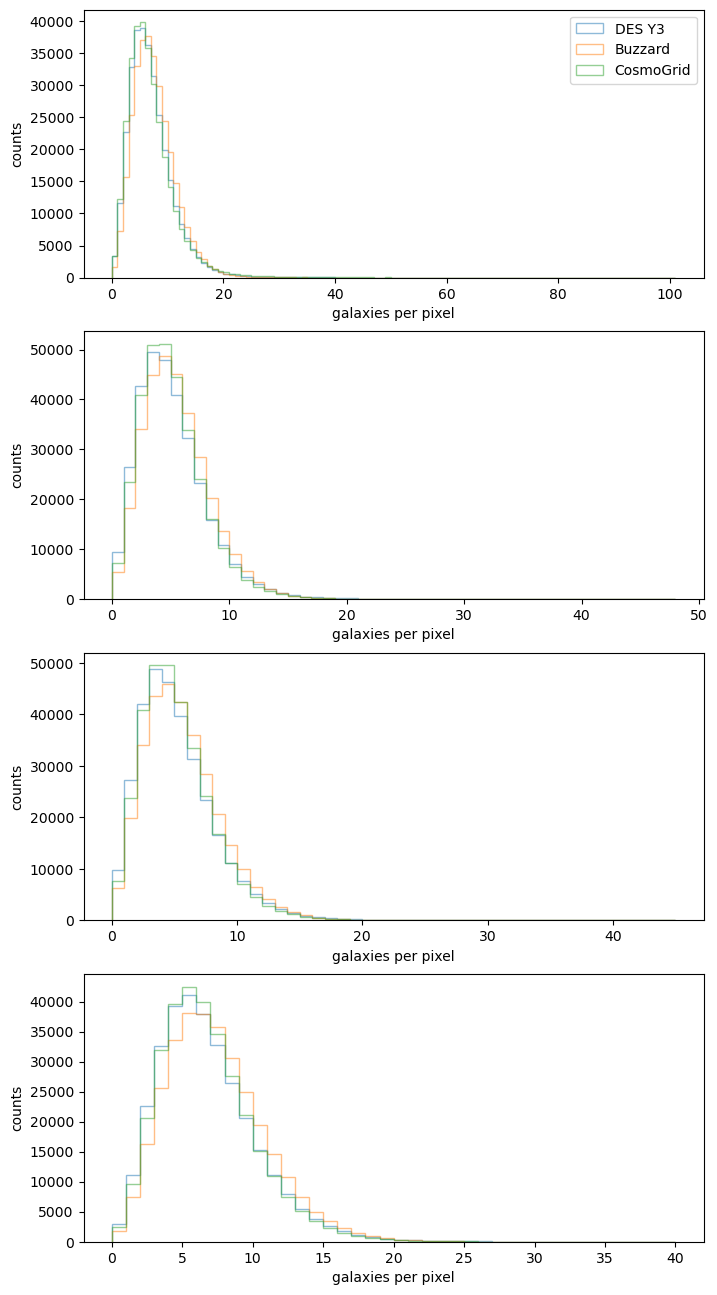

In [7]:
nrows = des_map.shape[-1]

fig, ax = plt.subplots(figsize=(8, 4 * nrows), nrows=nrows)

for i in range(nrows):
    des = des_fp[:,i]
    buz = buz_fp[:,i]
    grid = grid_fp[:,i]
    
    bins = np.arange(np.min([des, buz, grid]), np.max([des, buz, grid]))
    
    ax[i].hist(des, bins=bins, label="DES Y3", color="tab:blue", alpha=0.5, histtype="step")
    ax[i].hist(buz, bins=bins, label="Buzzard", color="tab:orange", alpha=0.5, histtype="step")
    ax[i].hist(grid, bins=bins, label="CosmoGrid", color="tab:green", alpha=0.5, histtype="step")

    ax[i].set(xlabel="galaxies per pixel", ylabel="counts")

ax[0].legend()

# forward-modeled (non padded) data vector

In [8]:
# check total galaxy counts
print("DES", np.sum(des_fm, axis=0))
print("Buzzard", np.sum(buz_fm, axis=0))
print("CosmoGrid", np.sum(grid_fm, axis=0))

DES [332545.44 243071.1  245425.81 331556.66]
Buzzard [371448.84 262402.03 269157.7  362186.03]
CosmoGrid [344559.84 242979.17 245863.95 328553.44]


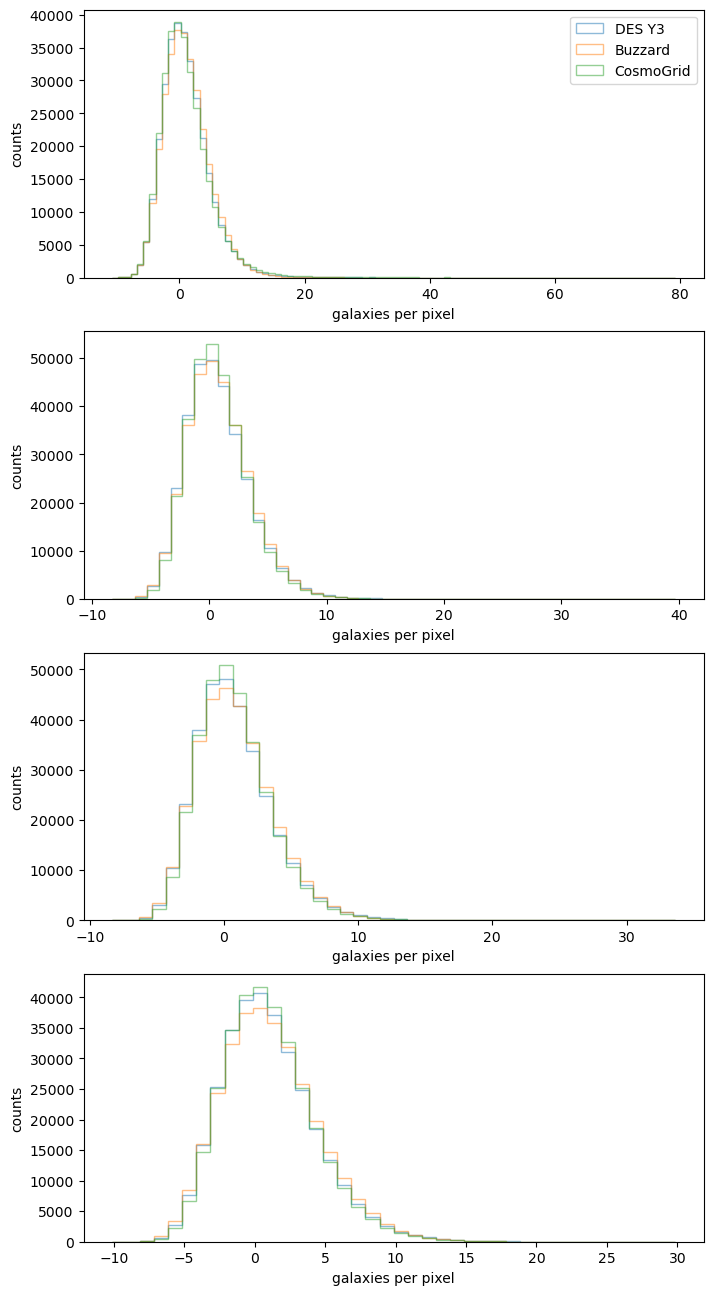

In [9]:
nrows = des_map.shape[-1]

fig, ax = plt.subplots(figsize=(8, 4 * nrows), nrows=nrows)

for i in range(nrows):
    des = des_fm[:,i]
    buz = buz_fm[:,i]
    grid = grid_fm[:,i]
    
    bins = np.arange(np.min([des, buz, grid]), np.max([des, buz, grid]))
    
    ax[i].hist(des, bins=bins, label="DES Y3", color="tab:blue", alpha=0.5, histtype="step")
    ax[i].hist(buz, bins=bins, label="Buzzard", color="tab:orange", alpha=0.5, histtype="step")
    ax[i].hist(grid, bins=bins, label="CosmoGrid", color="tab:green", alpha=0.5, histtype="step")

    ax[i].set(xlabel="galaxies per pixel", ylabel="counts")

ax[0].legend()